In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

df = pd.read_csv("../../data/cleaned/mvp/cleaned_data_v1.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nFirst 5 rows:")
display(df.head())

Shape: (62559, 8)

Columns:
['race_id', 'meet_date', 'venue', 'race_no', 'horse_name', 'horse_seq', 'placing_num', 'odds_decimal']

Dtypes:
race_id             str
meet_date           str
venue               str
race_no           int64
horse_name          str
horse_seq         int64
placing_num     float64
odds_decimal    float64
dtype: object

Missing values:
race_id         0
meet_date       0
venue           0
race_no         0
horse_name      0
horse_seq       0
placing_num     0
odds_decimal    0
dtype: int64

First 5 rows:


,race_id,meet_date,venue,race_no,horse_name,horse_seq,placing_num,odds_decimal
0,15-07-2010_Mumbai_1,15-07-2010,Mumbai,1,RISING GLORY,12346,1.000000,3.750000
1,15-07-2010_Mumbai_1,15-07-2010,Mumbai,1,CANDY FLOSS,12432,2.000000,8.000000
2,15-07-2010_Mumbai_1,15-07-2010,Mumbai,1,CHINGARI,12480,3.000000,7.500000
3,15-07-2010_Mumbai_1,15-07-2010,Mumbai,1,BENEDICTUS,12199,4.000000,13.000000
4,15-07-2010_Mumbai_1,15-07-2010,Mumbai,1,THE FIRST LADY,11701,5.000000,6.000000


In [6]:
print("Unique races:", df["race_id"].nunique())

print("\nOdds summary:")
print(df["odds_decimal"].describe(percentiles=[0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]))

print("\nOdds <= 1:")
print(df[df["odds_decimal"] <= 1][["race_id", "horse_name", "odds_decimal"]])

print("\nOdds <= 0:")
print(df[df["odds_decimal"] <= 0][["race_id", "horse_name", "odds_decimal"]])

print("\nTop 20 largest odds:")
display(
    df.nlargest(20, "odds_decimal")[
        ["race_id", "horse_name", "placing_num", "odds_decimal"]
    ]
)

print("\nTop 20 smallest odds:")
display(
    df.nsmallest(20, "odds_decimal")[
        ["race_id", "horse_name", "placing_num", "odds_decimal"]
    ]
)

Unique races: 6736

Odds summary:
count   62559.000000
mean       14.793378
std        11.327924
min         1.010000
0.1%        1.350000
1%          1.700000
5%          2.600000
25%         6.500000
50%        13.000000
75%        21.000000
95%        36.000000
99%        56.000000
99.9%     100.000000
max       101.000000
Name: odds_decimal, dtype: float64

Odds <= 1:
Empty DataFrame
Columns: [race_id, horse_name, odds_decimal]
Index: []

Odds <= 0:
Empty DataFrame
Columns: [race_id, horse_name, odds_decimal]
Index: []

Top 20 largest odds:


,race_id,horse_name,placing_num,odds_decimal
61081,12-10-2025_Pune_124,MIRACLE OF HANUKAH,5.000000,101.000000
1907,10-10-2010_Mumbai_206,ROB N ROB,7.000000,100.000000
1909,10-10-2010_Mumbai_206,EVANGILIST,9.000000,100.000000
1910,10-10-2010_Mumbai_206,INDIAN CHIEF,10.000000,100.000000
1919,10-10-2010_Mumbai_207,GAME OF POWER,9.000000,100.000000
1921,10-10-2010_Mumbai_207,TABAR,11.000000,100.000000
1935,10-10-2010_Mumbai_208,TINTORETTO,14.000000,100.000000
6937,11-09-2011_Pune_135,AWESOME SMILE,5.000000,100.000000
6939,11-09-2011_Pune_135,CHARLIE COOL,7.000000,100.000000
7415,08-10-2011_Pune_187,ITSMYWAY,7.000000,100.000000



Top 20 smallest odds:


,race_id,horse_name,placing_num,odds_decimal
9570,04-02-2012_Mumbai_173,ELENA,1.000000,1.010000
26500,04-01-2015_Mumbai_110,BE SAFE,1.000000,1.010000
8047,20-11-2011_Mumbai_17,CARDINAL,1.000000,1.100000
4112,13-02-2011_Mumbai_194,HEIRESS,6.000000,1.110000
10192,26-02-2012_Mumbai_234,RISKY BUSINESS,3.000000,1.110000
41206,03-12-2017_Mumbai_29,ZENON,1.000000,1.150000
53423,22-01-2023_Mumbai_80,HUNTING GODDESS,1.000000,1.150000
38199,19-02-2017_Mumbai_173,MATHAIYUS,1.000000,1.180000
42090,21-01-2018_Mumbai_134,RIQUEWIHR,2.000000,1.180000
40983,19-11-2017_Mumbai_2,RUFFINA,1.000000,1.190000


In [7]:
# Implied probability from decimal odds
df["implied_prob"] = 1 / df["odds_decimal"]

# Race-level sum of implied probabilities
df["implied_prob_sum"] = df.groupby("race_id")["implied_prob"].transform("sum")

# Race-level overround
df["overround"] = df["implied_prob_sum"] - 1

# Normalized market probability
df["market_prob"] = df["implied_prob"] / df["implied_prob_sum"]

# Race-level market entropy
df["market_entropy"] = (
    -df["market_prob"] * np.log2(df["market_prob"])
)

df["market_entropy"] = df.groupby("race_id")["market_entropy"].transform("sum")

print("Runner-level checks:")
print(df[[
    "odds_decimal",
    "implied_prob",
    "market_prob",
    "overround",
    "market_entropy"
]].head(10))

Runner-level checks:
   odds_decimal  implied_prob  market_prob  overround  market_entropy
0      3.750000      0.266667     0.254701   0.046978        2.832120
1      8.000000      0.125000     0.119391   0.046978        2.832120
2      7.500000      0.133333     0.127351   0.046978        2.832120
3     13.000000      0.076923     0.073472   0.046978        2.832120
4      6.000000      0.166667     0.159188   0.046978        2.832120
5     13.000000      0.076923     0.073472   0.046978        2.832120
6      6.500000      0.153846     0.146943   0.046978        2.832120
7     21.000000      0.047619     0.045482   0.046978        2.832120
8      8.000000      0.125000     0.123532   0.011880        2.665033
9      7.000000      0.142857     0.141180   0.011880        2.665033


In [8]:
# Verify normalized probabilities sum to exactly 1 within each race
prob_sums = df.groupby("race_id")["market_prob"].sum()

print("\nNormalized probability sum:")
print(prob_sums.describe())

print("\nMaximum absolute deviation from 1:")
print(np.abs(prob_sums - 1).max())

print("\nNumber of races with deviation > 1e-10:")
print((np.abs(prob_sums - 1) > 1e-10).sum())


Normalized probability sum:
count   6736.000000
mean       1.000000
std        0.000000
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: market_prob, dtype: float64

Maximum absolute deviation from 1:
2.220446049250313e-16

Number of races with deviation > 1e-10:
0


In [9]:
race_market = (
    df.groupby("race_id")
      .agg(
          meet_date=("meet_date", "first"),
          venue=("venue", "first"),
          race_no=("race_no", "first"),
          runners=("horse_name", "size"),
          overround=("overround", "first"),
          entropy=("market_entropy", "first"),
      )
      .reset_index()
)

print("Race-level shape:", race_market.shape)

print("\nOverround summary:")
print(
    race_market["overround"]
    .describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

print("\nOverround as percentage:")
print(
    (race_market["overround"] * 100)
    .describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

print("\nNegative overround races:")
print((race_market["overround"] < 0).sum())

print("\nZero/negative implied margin races:")
display(
    race_market[race_market["overround"] <= 0]
    .sort_values("overround")
    .head(20)
)

print("\nHighest overround races:")
display(
    race_market.nlargest(20, "overround")[
        ["race_id", "meet_date", "venue", "race_no",
         "runners", "overround", "entropy"]
    ]
)

Race-level shape: (6736, 7)

Overround summary:
count   6736.000000
mean       0.161550
std        0.167812
min       -0.693539
1%        -0.161112
5%        -0.053568
10%       -0.023345
25%        0.042720
50%        0.141172
75%        0.256237
90%        0.382148
95%        0.463641
99%        0.643840
max        1.008152
Name: overround, dtype: float64

Overround as percentage:
count   6736.000000
mean      16.155008
std       16.781152
min      -69.353865
1%       -16.111244
5%        -5.356836
10%       -2.334540
25%        4.271993
50%       14.117198
75%       25.623658
90%       38.214841
95%       46.364087
99%       64.383952
max      100.815198
Name: overround, dtype: float64

Negative overround races:
1009

Zero/negative implied margin races:


,race_id,meet_date,venue,race_no,runners,overround,entropy
2410,13-03-2014_Mumbai_261,13-03-2014,Mumbai,261,5,-0.693539,2.094084
524,03-10-2014_Pune_177,03-10-2014,Pune,177,3,-0.673077,1.489353
5731,26-08-2023_Pune_52,26-08-2023,Pune,52,3,-0.655220,1.540201
1101,06-08-2011_Pune_38,06-08-2011,Pune,38,8,-0.617837,2.822185
882,05-08-2012_Pune_31,05-08-2012,Pune,31,4,-0.587773,1.323889
2424,13-03-2022_Mumbai_123,13-03-2022,Mumbai,123,5,-0.562958,2.023641
572,04-01-2015_Mumbai_108,04-01-2015,Mumbai,108,5,-0.547554,2.235831
4331,21-01-2024_Mumbai_83,21-01-2024,Mumbai,83,3,-0.515152,1.494785
1027,06-02-2022_Mumbai_81,06-02-2022,Mumbai,81,6,-0.505069,1.988714
2332,12-10-2025_Pune_123,12-10-2025,Pune,123,6,-0.493777,2.431619



Highest overround races:


,race_id,meet_date,venue,race_no,runners,overround,entropy
4066,19-12-2021_Mumbai_13,19-12-2021,Mumbai,13,7,1.008152,1.939540
1012,06-02-2011_Mumbai_187,06-02-2011,Mumbai,187,22,1.000507,4.156032
745,04-12-2016_Mumbai_36,04-12-2016,Mumbai,36,21,0.929146,4.132819
819,05-02-2012_Mumbai_190,05-02-2012,Mumbai,190,18,0.909691,3.930999
2760,14-10-2017_Pune_167,14-10-2017,Pune,167,19,0.884128,4.112982
5155,24-04-2011_Mumbai_362,24-04-2011,Mumbai,362,16,0.882326,3.369627
1316,07-08-2011_Pune_47,07-08-2011,Pune,47,21,0.869899,4.071623
1958,10-09-2017_Pune_112,10-09-2017,Pune,112,17,0.851537,3.899710
5783,26-10-2019_Pune_157,26-10-2019,Pune,157,16,0.849248,3.906230
2861,15-02-2019_Mumbai_150,15-02-2019,Mumbai,150,14,0.835042,3.717070


In [10]:
negative_races = (
    race_market[race_market["overround"] < 0]
    .sort_values("overround")
)

print("Negative-overround races:", len(negative_races))
print("Percentage:", len(negative_races) / len(race_market) * 100)

# Inspect the 10 most extreme races
extreme_ids = negative_races.head(10)["race_id"].tolist()

for race_id in extreme_ids:
    race = df[df["race_id"] == race_id].copy()

    print("\n" + "=" * 80)
    print(race_id)

    display(
        race[
            [
                "horse_name",
                "placing_num",
                "odds_decimal",
                "implied_prob",
                "market_prob",
            ]
        ].sort_values("odds_decimal")
    )

    print(
        "Implied probability sum:",
        race["implied_prob"].sum(),
        "| Overround:",
        race["overround"].iloc[0]
    )

Negative-overround races: 1009
Percentage: 14.979216152019003

13-03-2014_Mumbai_261


,horse_name,placing_num,odds_decimal,implied_prob,market_prob
22403,JACK FROST,1.000000,9.000000,0.111111,0.362562
22404,SUNNY SEA,2.000000,12.000000,0.083333,0.271921
22407,LIGHT OF ARABIA,5.000000,16.000000,0.062500,0.203941
22405,THEORY,3.000000,36.000000,0.027778,0.090640
22406,MIDNIGHT DANCER,4.000000,46.000000,0.021739,0.070936


Implied probability sum: 0.3064613526570048 | Overround: -0.6935386473429952

03-10-2014_Pune_177


,horse_name,placing_num,odds_decimal,implied_prob,market_prob
24961,SQUARE MOON,1.000000,6.000000,0.166667,0.509804
24962,MUFASA,2.000000,12.000000,0.083333,0.254902
24963,YODHA SHAKTI,3.000000,13.000000,0.076923,0.235294


Implied probability sum: 0.3269230769230769 | Overround: -0.6730769230769231

26-08-2023_Pune_52


...

Implied probability sum: 0.48484848484848486 | Overround: -0.5151515151515151

06-02-2022_Mumbai_81


,horse_name,placing_num,odds_decimal,implied_prob,market_prob
50650,SUPERNATURAL,1.000000,3.700000,0.270270,0.546076
50652,SHABELLE,3.000000,13.000000,0.076923,0.155422
50653,O HANSINI,4.000000,19.000000,0.052632,0.106341
50651,LAST WISH,2.000000,26.000000,0.038462,0.077711
50654,DEAR LADY,5.000000,27.000000,0.037037,0.074833
50655,MUFAZA,6.000000,51.000000,0.019608,0.039617


Implied probability sum: 0.494931344776546 | Overround: -0.505068655223454

12-10-2025_Pune_123


,horse_name,placing_num,odds_decimal,implied_prob,market_prob
61071,MAGILETO,1.000000,6.000000,0.166667,0.329236
61073,DUBAI PRINCESS,3.000000,11.000000,0.090909,0.179583
61074,DREAM SELLER,4.000000,11.000000,0.090909,0.179583
61076,CONSTABLE,6.000000,16.000000,0.062500,0.123463
61072,CHRISTOPHANY,2.000000,21.000000,0.047619,0.094067
61075,MARKET KING,5.000000,21.000000,0.047619,0.094067


Implied probability sum: 0.5062229437229437 | Overround: -0.49377705627705626


In [11]:
race_market["overround_pct"] = race_market["overround"] * 100

print("Negative overround by venue:")
print(
    race_market[race_market["overround"] < 0]
    .groupby("venue")
    .size()
    .sort_values(ascending=False)
)

print("\nNegative overround by year:")
race_market["year"] = pd.to_datetime(
    race_market["meet_date"],
    format="%d-%m-%Y"
).dt.year

print(
    race_market[race_market["overround"] < 0]
    .groupby("year")
    .size()
)

print("\nOverall race counts by venue:")
print(race_market["venue"].value_counts())

print("\nOverround by venue:")
print(
    race_market.groupby("venue")["overround"]
    .agg(["count", "mean", "median", "min", "max"])
)

print("\nNegative overround by number of runners:")
print(
    race_market[race_market["overround"] < 0]
    .groupby("runners")
    .size()
    .sort_index()
)

Negative overround by venue:
venue
Mumbai    721
Pune      288
dtype: int64

Negative overround by year:
year
2010     44
2011     73
2012     98
2013    147
2014    123
2015    134
2016     92
2017     55
2018     32
2019     32
2020     25
2021      4
2022     41
2023     23
2024     46
2025     36
2026      4
dtype: int64

Overall race counts by venue:
venue
Mumbai    4230
Pune      2506
Name: count, dtype: int64

Overround by venue:
        count     mean   median       min      max
venue                                             
Mumbai   4230 0.145781 0.125213 -0.693539 1.008152
Pune     2506 0.188168 0.172990 -0.673077 0.884128

Negative overround by number of runners:
runners
2       8
3      71
4     235
5     246
6     182
7     124
8      63
9      37
10     19
11     13
12      8
13      2
15      1
dtype: int64


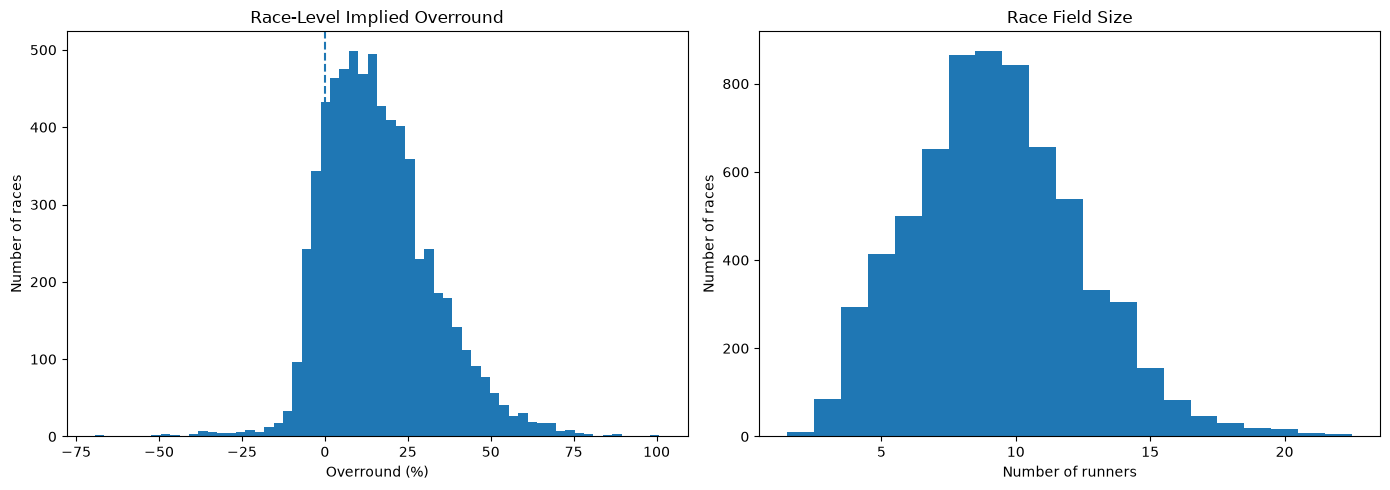

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overround distribution
axes[0].hist(
    race_market["overround_pct"],
    bins=60
)
axes[0].axvline(0, linestyle="--")
axes[0].set_title("Race-Level Implied Overround")
axes[0].set_xlabel("Overround (%)")
axes[0].set_ylabel("Number of races")

# Runners distribution
axes[1].hist(
    race_market["runners"],
    bins=np.arange(
        race_market["runners"].min() - 0.5,
        race_market["runners"].max() + 1.5,
        1
    )
)
axes[1].set_title("Race Field Size")
axes[1].set_xlabel("Number of runners")
axes[1].set_ylabel("Number of races")

plt.tight_layout()
plt.show()

In [13]:
print("Field size summary:")
print(race_market["runners"].describe())

print("\nOverround quantiles (%):")
print(
    race_market["overround_pct"]
    .quantile([
        0, .01, .05, .10, .25, .50,
        .75, .90, .95, .99, 1
    ])
)

Field size summary:
count   6736.000000
mean       9.287262
std        3.159486
min        2.000000
25%        7.000000
50%        9.000000
75%       11.000000
max       22.000000
Name: runners, dtype: float64

Overround quantiles (%):
0.000000   -69.353865
0.010000   -16.111244
0.050000    -5.356836
0.100000    -2.334540
0.250000     4.271993
0.500000    14.117198
0.750000    25.623658
0.900000    38.214841
0.950000    46.364087
0.990000    64.383952
1.000000   100.815198
Name: overround_pct, dtype: float64


In [14]:
field_overround = (
    race_market
    .groupby("runners")
    .agg(
        races=("race_id", "count"),
        mean_overround=("overround_pct", "mean"),
        median_overround=("overround_pct", "median"),
        negative_overround_pct=(
            "overround_pct",
            lambda x: (x < 0).mean() * 100
        )
    )
    .reset_index()
)

field_overround

,runners,races,mean_overround,median_overround,negative_overround_pct
0,2,10,-9.699312,-4.656488,80.000000
1,3,85,-7.216893,-4.689833,83.529412
2,4,294,-3.455081,-2.939604,79.931973
3,5,414,-1.660222,-1.170442,59.420290
4,6,501,1.776612,2.042219,36.327345
5,7,653,5.409358,5.824830,18.989280
6,8,866,10.392002,10.455648,7.274827
7,9,875,14.724973,15.068265,4.228571
8,10,843,19.237706,19.848485,2.253855
9,11,656,23.120831,23.683136,1.981707


In [15]:
print(
    field_overround.to_string(index=False)
)

 runners  races  mean_overround  median_overround  negative_overround_pct
       2     10       -9.699312         -4.656488               80.000000
       3     85       -7.216893         -4.689833               83.529412
       4    294       -3.455081         -2.939604               79.931973
       5    414       -1.660222         -1.170442               59.420290
       6    501        1.776612          2.042219               36.327345
       7    653        5.409358          5.824830               18.989280
       8    866       10.392002         10.455648                7.274827
       9    875       14.724973         15.068265                4.228571
      10    843       19.237706         19.848485                2.253855
      11    656       23.120831         23.683136                1.981707
      12    538       27.707855         27.990038                1.486989
      13    333       33.589538         34.300724                0.600601
      14    304       38.925689       

In [16]:
from scipy.stats import spearmanr, pearsonr

x = race_market["runners"]
y = race_market["overround"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson correlation : {pearson_r:.4f}  (p={pearson_p:.4e})")
print(f"Spearman correlation: {spearman_r:.4f}  (p={spearman_p:.4e})")

Pearson correlation : 0.7729  (p=0.0000e+00)
Spearman correlation: 0.8081  (p=0.0000e+00)


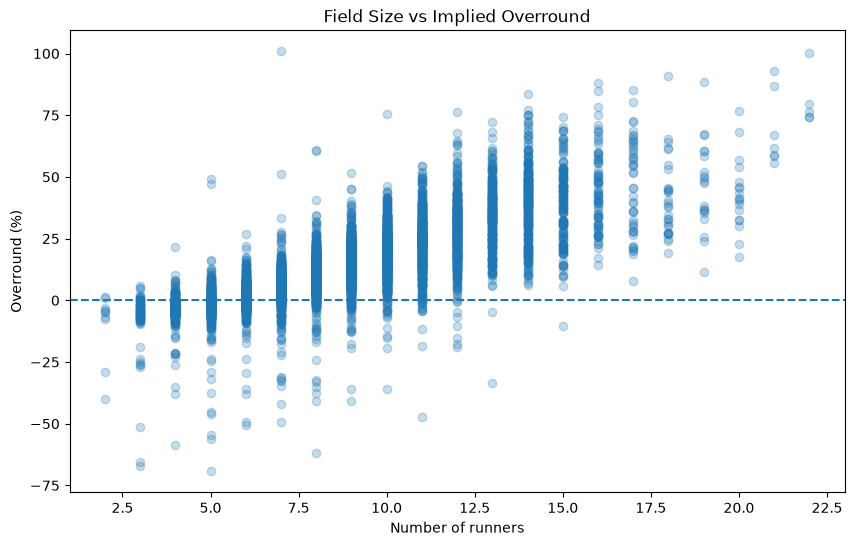

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    race_market["runners"],
    race_market["overround_pct"],
    alpha=0.25
)

plt.axhline(0, linestyle="--")

plt.xlabel("Number of runners")
plt.ylabel("Overround (%)")
plt.title("Field Size vs Implied Overround")

plt.show()

In [18]:
df["is_winner"] = (df["placing_num"] == 1).astype(int)

df["odds_band"] = pd.cut(
    df["odds_decimal"],
    bins=[1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 101],
    right=False
)

fav_bias = (
    df.groupby("odds_band", observed=True)
      .agg(
          runners=("race_id", "size"),
          races=("race_id", "nunique"),
          mean_odds=("odds_decimal", "mean"),
          mean_market_prob=("market_prob", "mean"),
          actual_win_rate=("is_winner", "mean")
      )
      .reset_index()
)

fav_bias["calibration_error"] = (
    fav_bias["actual_win_rate"]
    - fav_bias["mean_market_prob"]
)

fav_bias

,odds_band,runners,races,mean_odds,mean_market_prob,actual_win_rate,calibration_error
0,"[1, 2)",1313,1310,1.696915,0.542482,0.620716,0.078234
1,"[2, 3)",3058,2839,2.464918,0.361204,0.429693,0.068488
2,"[3, 5)",6057,4164,3.877550,0.230013,0.270596,0.040583
3,"[5, 8)",8004,4769,6.240639,0.140280,0.162419,0.022139
4,"[8, 12)",11229,5369,9.684901,0.087805,0.087363,-0.000442
5,"[12, 20)",13564,5524,14.811191,0.056512,0.035019,-0.021492
6,"[20, 30)",14120,5005,22.059348,0.037778,0.013244,-0.024534
7,"[30, 50)",3685,1796,35.728087,0.025269,0.009227,-0.016042
8,"[50, 75)",1372,750,54.713557,0.016466,0.001458,-0.015008
9,"[75, 101)",156,104,91.679487,0.009933,0.012821,0.002887


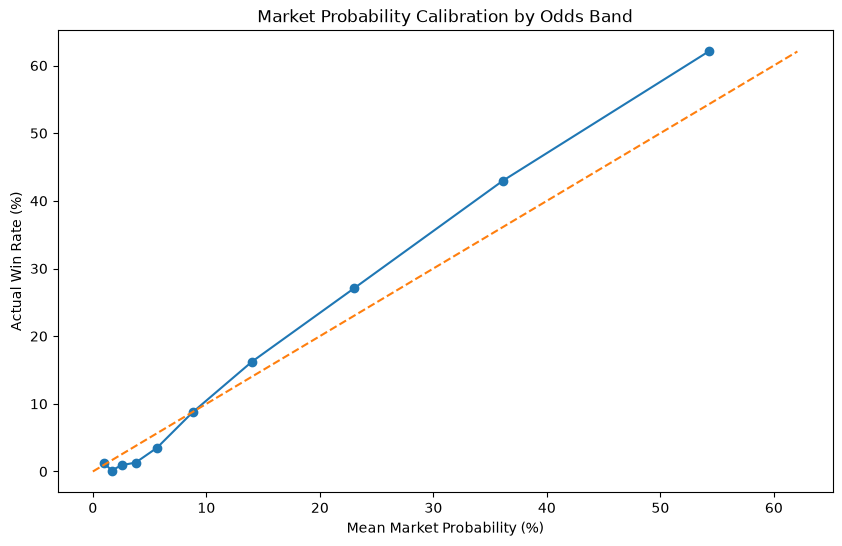

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    fav_bias["mean_market_prob"] * 100,
    fav_bias["actual_win_rate"] * 100,
    marker="o"
)

# Perfect calibration line
max_prob = max(
    fav_bias["mean_market_prob"].max(),
    fav_bias["actual_win_rate"].max()
) * 100

plt.plot(
    [0, max_prob],
    [0, max_prob],
    linestyle="--"
)

plt.xlabel("Mean Market Probability (%)")
plt.ylabel("Actual Win Rate (%)")
plt.title("Market Probability Calibration by Odds Band")

plt.show()

In [20]:
fav_bias["actual_to_expected"] = (
    fav_bias["actual_win_rate"]
    / fav_bias["mean_market_prob"]
)

print(
    fav_bias[
        [
            "odds_band",
            "runners",
            "mean_market_prob",
            "actual_win_rate",
            "actual_to_expected"
        ]
    ].to_string(index=False)
)

odds_band  runners  mean_market_prob  actual_win_rate  actual_to_expected
   [1, 2)     1313          0.542482         0.620716            1.144214
   [2, 3)     3058          0.361204         0.429693            1.189611
   [3, 5)     6057          0.230013         0.270596            1.176435
   [5, 8)     8004          0.140280         0.162419            1.157822
  [8, 12)    11229          0.087805         0.087363            0.994970
 [12, 20)    13564          0.056512         0.035019            0.619681
 [20, 30)    14120          0.037778         0.013244            0.350568
 [30, 50)     3685          0.025269         0.009227            0.365138
 [50, 75)     1372          0.016466         0.001458            0.088530
[75, 101)      156          0.009933         0.012821            1.290670


In [21]:
df["field_size_band"] = pd.cut(
    df.groupby("race_id")["race_id"].transform("size"),
    bins=[1, 5, 8, 11, 15, 22],
    labels=["2-5", "6-8", "9-11", "12-15", "16-22"],
    include_lowest=True
)

field_bias = (
    df.groupby(
        ["field_size_band", "odds_band"],
        observed=True
    )
    .agg(
        runners=("race_id", "size"),
        mean_market_prob=("market_prob", "mean"),
        actual_win_rate=("is_winner", "mean")
    )
    .reset_index()
)

field_bias["actual_to_expected"] = (
    field_bias["actual_win_rate"]
    / field_bias["mean_market_prob"]
)

field_bias

,field_size_band,odds_band,runners,mean_market_prob,actual_win_rate,actual_to_expected
0,2-5,"[1, 2)",318,0.631958,0.660377,1.044971
1,2-5,"[2, 3)",472,0.422403,0.442797,1.048281
2,2-5,"[3, 5)",688,0.277448,0.283430,1.021560
3,2-5,"[5, 8)",580,0.173256,0.191379,1.104606
4,2-5,"[8, 12)",499,0.110549,0.098196,0.888262
5,2-5,"[12, 20)",502,0.073923,0.047809,0.646741
6,2-5,"[20, 30)",333,0.046531,0.018018,0.387223
7,2-5,"[30, 50)",97,0.030182,0.000000,0.000000
8,2-5,"[50, 75)",26,0.020328,0.000000,0.000000
9,2-5,"[75, 101)",6,0.011059,0.000000,0.000000


In [22]:
print(
    field_bias.to_string(index=False)
)

field_size_band odds_band  runners  mean_market_prob  actual_win_rate  actual_to_expected
            2-5    [1, 2)      318          0.631958         0.660377            1.044971
            2-5    [2, 3)      472          0.422403         0.442797            1.048281
            2-5    [3, 5)      688          0.277448         0.283430            1.021560
            2-5    [5, 8)      580          0.173256         0.191379            1.104606
            2-5   [8, 12)      499          0.110549         0.098196            0.888262
            2-5  [12, 20)      502          0.073923         0.047809            0.646741
            2-5  [20, 30)      333          0.046531         0.018018            0.387223
            2-5  [30, 50)       97          0.030182         0.000000            0.000000
            2-5  [50, 75)       26          0.020328         0.000000            0.000000
            2-5 [75, 101)        6          0.011059         0.000000            0.000000
          